# TCC Mara - Projeto 04

## Análise do impacto de fatores sociodemográficos na taxa de conclusão de cursos nos Instutos Federais de Educação no Brasil

### Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

### Extração, Limpeza e Transformação dos Dados

#### Extração dos dados 

Neste estudo, foi utilizado o conjunto de dados consolidado: Dados Acadêmicos - Classificação Racial, Renda, SEXO e Faixa Etária da plataforma Nilo Peçanha (https://moduloextratorpnp.mec.gov.br/pnpquery/5), aqui denominado de Candidatos.csv, para analisar a probabilidade de sucesso (Taxa de Conclusão) de acordo com o perfil demográfico do aluno (Cor, Renda, Idade, Gênero) na Rede Federal.

In [8]:
# Leitura do arquivo
df = pd.read_csv('../Data/Candidatos.csv', sep=';', encoding='utf-8')
df.shape

(244006, 15)

#### Limpeza dos dados

Antes de iniciar as análises estatísticas, os dados passaram por processo de preparação e limpeza com as seguintes etapas:

##### **Etapa 1:** Padronização das variáveis e observações:

Neste etapa, foram removidos espaços em branco desnecessários (trailing/leading spaces) dos nomes das colunas e dos valores textuais, garantindo consistência na manipulação das strings.

In [9]:
# Limpeza de strings
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

In [10]:
# Renomeação das colunas (variáveis)
df = df.rename(columns={
    'Ano':'ANO', 
    'Região':'REG', 
    'UF':'UF_SIGLA', 
    'Estado':'UF_NOME', 
    'Organização Acadêmica PNP':'ORG_ACAD',
    'Instituicao':'INST', 
    'Instituição (Nome)': 'INST_NOME', 
    'CorRaca':'RACA', 
    'RendaFamiliar':'RENDA',
    'FaixaEtaria':'FAIXA_ETARIA',
    'Sexo':'SEXO',
    'Número de concluintes':'CONCLUINTES',
    'Número de ingressantes':'INGRESSANTES',
    'Número de Matrículas':'MATRICULAS',
    'Número de vagas':'VAGAS'
})

##### **Etapa 2:** Filtro por Instituição

O estudo focou especificamente nos Institutos Federais de Ensino. Para isso, os dados foram filtrados para incluir apenas as instituições cujos nomes iniciavam com "IF" (Institutos Federais).

In [11]:
# Filtro para Institutos Federais
df = df[df['ORG_ACAD'] == 'Instituto Federal']
df.shape

(201550, 15)

##### **Etapa 3:** Tratamento de Dados Faltantes e Ruídos

Para evitar que a ausência de declaração distorcesse as análises de perfis demográficos específicos, foram excluídos todos os registros em que as variáveis de interesse (RACA, RENDA,FAIXA_ETARIA e SEXO) constavam como S/I (Sem Informação) ou Não Declarada.

In [12]:
# Remoção de classes sem informação declarada
remover = ['S/I', 'Não Declarada', 'Não declarada']
df = df[~df['RACA'].isin(remover)]
df = df[~df['RENDA'].isin(remover)]
df = df[~df['FAIXA_ETARIA'].isin(remover)]
df = df[~df['SEXO'].isin(remover)]

# Nas colunas numéricas, vazio (NaN) significa 0 alunos
df['CONCLUINTES'] = df['CONCLUINTES'].fillna(0)
df['INGRESSANTES'] = df['INGRESSANTES'].fillna(0)
df['VAGAS'] = df['VAGAS'].fillna(0)


print(f"Linhas válidas (após limpeza): {df.shape}")

Linhas válidas (após limpeza): (135428, 15)


#### Transformação dos dados

##### Formatação das observações da variável RENDA

In [13]:
# Dicionário de mapeamento
mapa_renda = {
    '0<RFP<=0,5': 'Muito-Baixa',
    '0,5<RFP<=1': 'Baixa',
    '1<RFP<=1,5': 'Média-Baixa',
    '1,5<RFP<=2,5': 'Média',
    '2,5<RFP<=3,5': 'Média-Alta',
    'RFP>3,5': 'Alta',
    'Não declarada': 'Não-Declarada'
}

# Substituir os valores na coluna do dataframe original
df['RENDA'] = df['RENDA'].map(mapa_renda).fillna(df['RENDA'])

df.head()

,ANO,REG,UF_SIGLA,UF_NOME,ORG_ACAD,INST,INST_NOME,RACA,RENDA,FAIXA_ETARIA,SEXO,CONCLUINTES,INGRESSANTES,MATRICULAS,VAGAS
1,2025,Centro-Oeste,DF,Distrito Federal,Instituto Federal,IFB,Instituto Federal de Brasília,Preta,Muito-Baixa,20 a 24,Masculino,11.0,17.0,55,851.0
2,2025,Centro-Oeste,DF,Distrito Federal,Instituto Federal,IFB,Instituto Federal de Brasília,Indígena,Muito-Baixa,50 a 54,Masculino,0.0,0.0,1,0.0
3,2025,Centro-Oeste,DF,Distrito Federal,Instituto Federal,IFB,Instituto Federal de Brasília,Indígena,Muito-Baixa,15 a 19,Masculino,0.0,0.0,1,0.0
4,2025,Centro-Oeste,DF,Distrito Federal,Instituto Federal,IFB,Instituto Federal de Brasília,Preta,Alta,20 a 24,Masculino,3.0,7.0,24,464.0
5,2025,Centro-Oeste,DF,Distrito Federal,Instituto Federal,IFB,Instituto Federal de Brasília,Preta,Baixa,20 a 24,Masculino,8.0,30.0,85,2079.0


### Análises estatísticas descritivas

#### REGIÃO

In [33]:
df_reg = df.groupby(['REG']).agg(
    TOTAL_INGRESSANTES =('INGRESSANTES', 'sum'),
    TOTAL_CONCLUINTES =('CONCLUINTES', 'sum')
).reset_index()

In [39]:
df_reg['TAXA_CONCLUSAO'] = (df_reg['TOTAL_CONCLUINTES']/df_reg['TOTAL_INGRESSANTES'])*100

df_reg.head()

,REG,TOTAL_INGRESSANTES,TOTAL_CONCLUINTES,TAXA_CONCLUSAO
0,Centro-Oeste,314234.0,131887.0,41.970952
1,Nordeste,550362.0,240182.0,43.640731
2,Norte,198900.0,97359.0,48.948718
3,Sudeste,727272.0,461347.0,63.435276
4,Sul,2708437.0,2126777.0,78.524145


#### Gráfico

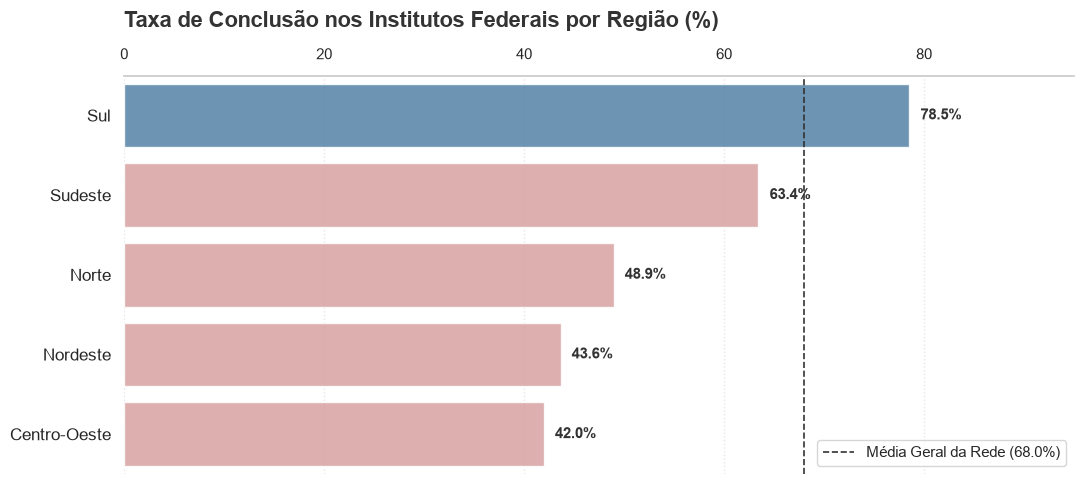

In [41]:
# 1. Ordenar o DataFrame de forma decrescente
df_reg = df_reg.sort_values(by='TAXA_CONCLUSAO', ascending=False).reset_index(drop=True)

# 2. Recalcular as cores na ordem decrescente exata
media_geral = (df['CONCLUINTES'].sum() / df['INGRESSANTES'].sum()) * 100
cores = ['#4682B4' if taxa >= media_geral else '#e09898' for taxa in df_reg['TAXA_CONCLUSAO']]

# 3. Gerar o gráfico
plt.figure(figsize=(11, 5))
ax = plt.gca()

sns.barplot(
    data=df_reg,
    x='TAXA_CONCLUSAO',
    y='REG',
    order=df_reg['REG'],  # <-- Garante Maior (Sul) no topo até o Menor (Centro-Oeste) na base
    palette=cores,
    alpha=0.85
)

# Linha de referência da média geral
plt.axvline(media_geral, color='#333333', linestyle='--', linewidth=1.2, label=f'Média Geral da Rede ({media_geral:.1f}%)')

plt.title('Taxa de Conclusão nos Institutos Federais por Região (%)', loc='left', pad=35, fontsize=16, weight='bold', color='#333333')
plt.xlabel('')
plt.ylabel('')

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.tick_params(axis='y', labelsize=12)

# Valores na ponta das barras
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.1f}%',
        (width, p.get_y() + p.get_height() / 2.),
        ha='left',
        va='center',
        xytext=(8, 0),
        textcoords='offset points',
        fontsize=11,
        weight='bold',
        color='#333333'
    )

ax.set_xlim(0, 95)
plt.grid(False, axis='y')
plt.grid(True, axis='x', linestyle=':', alpha=0.5, color='#cccccc')
sns.despine(left=True, bottom=True, top=False)
plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.tight_layout()
plt.show()


#### RACA

In [42]:
df_raca = df.groupby(['RACA']).agg(
    TOTAL_INGRESSANTES =('INGRESSANTES', 'sum'),
    TOTAL_CONCLUINTES =('CONCLUINTES', 'sum')
).reset_index()

In [43]:
df_raca['TAXA_CONCLUSAO'] = (df_raca['TOTAL_CONCLUINTES']/df_raca['TOTAL_INGRESSANTES'])*100

df_raca.head()

,RACA,TOTAL_INGRESSANTES,TOTAL_CONCLUINTES,TAXA_CONCLUSAO
0,Amarela,63784.0,46572.0,73.015176
1,Branca,1965841.0,1384876.0,70.447000
2,Indígena,26136.0,16490.0,63.093052
3,Parda,1927826.0,1272810.0,66.023075
4,Preta,515618.0,336804.0,65.320450


##### Gráfico

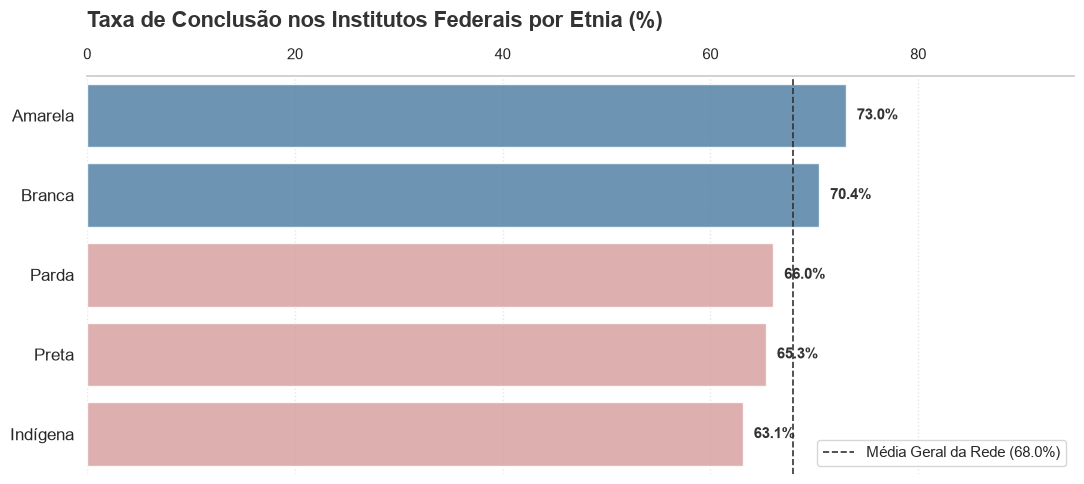

In [45]:
# 1. Ordenar o DataFrame de forma decrescente
df_raca = df_raca.sort_values(by='TAXA_CONCLUSAO', ascending=False).reset_index(drop=True)

# 2. Recalcular as cores na ordem decrescente exata
media_geral = (df['CONCLUINTES'].sum() / df['INGRESSANTES'].sum()) * 100
cores = ['#4682B4' if taxa >= media_geral else '#e09898' for taxa in df_raca['TAXA_CONCLUSAO']]

# 3. Gerar o gráfico
plt.figure(figsize=(11, 5))
ax = plt.gca()

sns.barplot(
    data=df_raca,
    x='TAXA_CONCLUSAO',
    y='RACA',
    order=df_raca['RACA'],  # <-- Garante Maior (Sul) no topo até o Menor (Centro-Oeste) na base
    palette=cores,
    alpha=0.85
)

# Linha de referência da média geral
plt.axvline(media_geral, color='#333333', linestyle='--', linewidth=1.2, label=f'Média Geral da Rede ({media_geral:.1f}%)')

plt.title('Taxa de Conclusão nos Institutos Federais por Etnia (%)', loc='left', pad=35, fontsize=16, weight='bold', color='#333333')
plt.xlabel('')
plt.ylabel('')

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.tick_params(axis='y', labelsize=12)

# Valores na ponta das barras
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.1f}%',
        (width, p.get_y() + p.get_height() / 2.),
        ha='left',
        va='center',
        xytext=(8, 0),
        textcoords='offset points',
        fontsize=11,
        weight='bold',
        color='#333333'
    )

ax.set_xlim(0, 95)
plt.grid(False, axis='y')
plt.grid(True, axis='x', linestyle=':', alpha=0.5, color='#cccccc')
sns.despine(left=True, bottom=True, top=False)
plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.tight_layout()
plt.show()


#### FAIXA_ETARIA

In [48]:
df_faixa_etaria = df.groupby(['FAIXA_ETARIA']).agg(
    TOTAL_INGRESSANTES =('INGRESSANTES', 'sum'),
    TOTAL_CONCLUINTES =('CONCLUINTES', 'sum')
).reset_index()

In [49]:
df_faixa_etaria['TAXA_CONCLUSAO'] = (df_faixa_etaria['TOTAL_CONCLUINTES']/df_faixa_etaria['TOTAL_INGRESSANTES'])*100

df_faixa_etaria.head()

,FAIXA_ETARIA,TOTAL_INGRESSANTES,TOTAL_CONCLUINTES,TAXA_CONCLUSAO
0,15 a 19,1000418.0,466885.0,46.668992
1,20 a 24,929932.0,683220.0,73.469888
2,25 a 29,697968.0,511991.0,73.354509
3,30 a 34,524989.0,379341.0,72.256943
4,35 a 39,443499.0,323750.0,72.999037


##### Gráfico

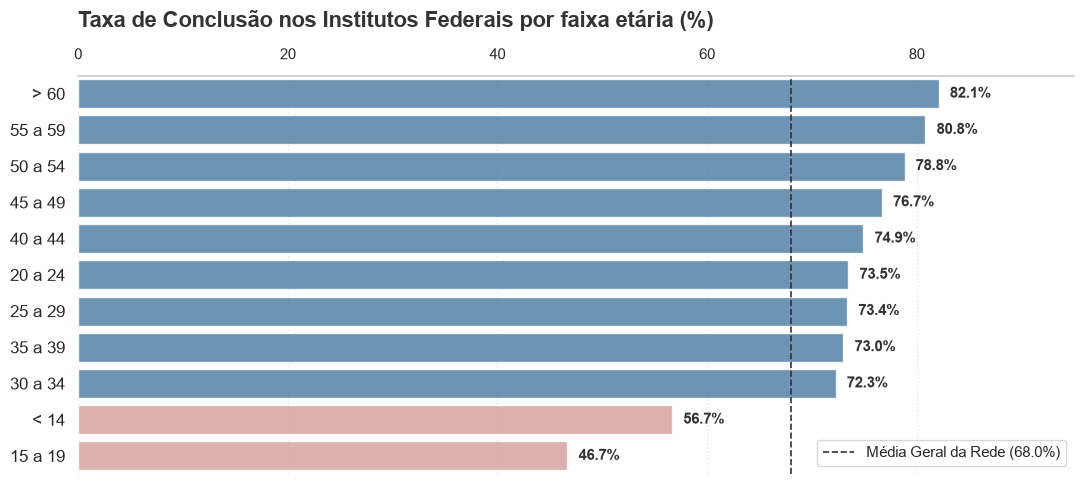

In [54]:
# 1. Ordenar o DataFrame de forma decrescente
df_faixa_etaria = df_faixa_etaria.sort_values(by='TAXA_CONCLUSAO', ascending=False).reset_index(drop=True)

# 2. Recalcular as cores na ordem decrescente exata
media_geral = (df['CONCLUINTES'].sum() / df['INGRESSANTES'].sum()) * 100
cores = ['#4682B4' if taxa >= media_geral else '#e09898' for taxa in df_faixa_etaria['TAXA_CONCLUSAO']]

# 3. Gerar o gráfico
plt.figure(figsize=(11, 5))
ax = plt.gca()

sns.barplot(
    data=df_faixa_etaria,
    x='TAXA_CONCLUSAO',
    y='FAIXA_ETARIA',
    order=df_faixa_etaria['FAIXA_ETARIA'],  # <-- Garante Maior (Sul) no topo até o Menor (Centro-Oeste) na base
    palette=cores,
    alpha=0.85
)

# Linha de referência da média geral
plt.axvline(media_geral, color='#333333', linestyle='--', linewidth=1.2, label=f'Média Geral da Rede ({media_geral:.1f}%)')

plt.title('Taxa de Conclusão nos Institutos Federais por faixa etária (%)', loc='left', pad=35, fontsize=16, weight='bold', color='#333333')
plt.xlabel('')
plt.ylabel('')

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.tick_params(axis='y', labelsize=12)

# Valores na ponta das barras
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.1f}%',
        (width, p.get_y() + p.get_height() / 2.),
        ha='left',
        va='center',
        xytext=(8, 0),
        textcoords='offset points',
        fontsize=11,
        weight='bold',
        color='#333333'
    )

ax.set_xlim(0, 95)
plt.grid(False, axis='y')
plt.grid(True, axis='x', linestyle=':', alpha=0.5, color='#cccccc')
sns.despine(left=True, bottom=True, top=False)
plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.tight_layout()
plt.show()


#### RENDA FAMILIAR

In [56]:
df_renda = df.groupby(['RENDA']).agg(
    TOTAL_INGRESSANTES =('INGRESSANTES', 'sum'),
    TOTAL_CONCLUINTES =('CONCLUINTES', 'sum')
).reset_index()

In [57]:
df_renda['TAXA_CONCLUSAO'] = (df_renda['TOTAL_CONCLUINTES']/df_renda['TOTAL_INGRESSANTES'])*100

df_renda.head()

,RENDA,TOTAL_INGRESSANTES,TOTAL_CONCLUINTES,TAXA_CONCLUSAO
0,Alta,423212.0,318891.0,75.350179
1,Baixa,1052408.0,700468.0,66.558597
2,Muito-Baixa,926066.0,541050.0,58.424562
3,Média,746049.0,535739.0,71.810163
4,Média-Alta,370023.0,277247.0,74.926964


#### Gráfico

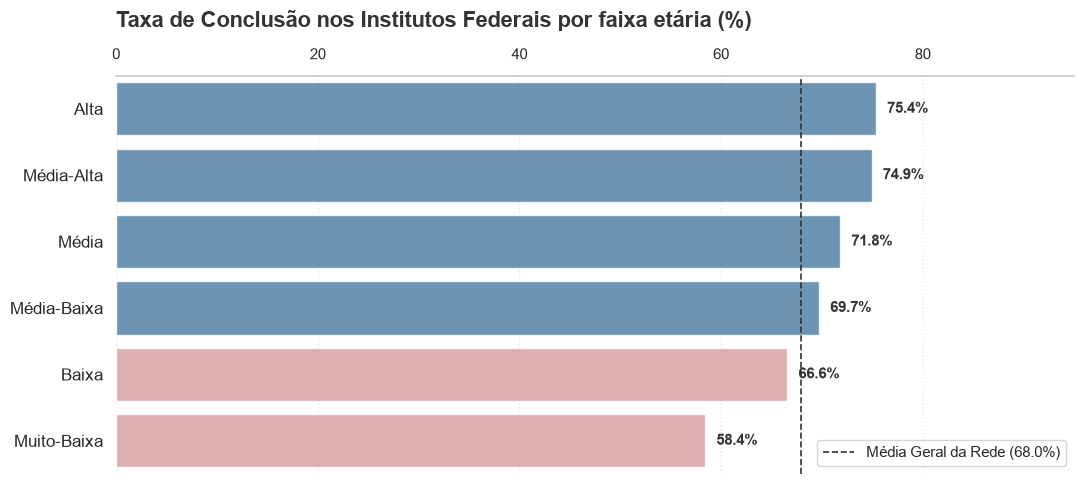

In [58]:
# 1. Ordenar o DataFrame de forma decrescente
df_renda = df_renda.sort_values(by='TAXA_CONCLUSAO', ascending=False).reset_index(drop=True)

# 2. Recalcular as cores na ordem decrescente exata
media_geral = (df['CONCLUINTES'].sum() / df['INGRESSANTES'].sum()) * 100
cores = ['#4682B4' if taxa >= media_geral else '#e09898' for taxa in df_renda['TAXA_CONCLUSAO']]

# 3. Gerar o gráfico
plt.figure(figsize=(11, 5))
ax = plt.gca()

sns.barplot(
    data=df_renda,
    x='TAXA_CONCLUSAO',
    y='RENDA',
    order=df_renda['RENDA'],  # <-- Garante Maior (Sul) no topo até o Menor (Centro-Oeste) na base
    palette=cores,
    alpha=0.85
)

# Linha de referência da média geral
plt.axvline(media_geral, color='#333333', linestyle='--', linewidth=1.2, label=f'Média Geral da Rede ({media_geral:.1f}%)')

plt.title('Taxa de Conclusão nos Institutos Federais por faixa etária (%)', loc='left', pad=35, fontsize=16, weight='bold', color='#333333')
plt.xlabel('')
plt.ylabel('')

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.tick_params(axis='y', labelsize=12)

# Valores na ponta das barras
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.1f}%',
        (width, p.get_y() + p.get_height() / 2.),
        ha='left',
        va='center',
        xytext=(8, 0),
        textcoords='offset points',
        fontsize=11,
        weight='bold',
        color='#333333'
    )

ax.set_xlim(0, 95)
plt.grid(False, axis='y')
plt.grid(True, axis='x', linestyle=':', alpha=0.5, color='#cccccc')
sns.despine(left=True, bottom=True, top=False)
plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.tight_layout()
plt.show()


#### SEXO

In [59]:
df_sexo = df.groupby(['SEXO']).agg(
    TOTAL_INGRESSANTES =('INGRESSANTES', 'sum'),
    TOTAL_CONCLUINTES =('CONCLUINTES', 'sum')
).reset_index()

In [60]:
df_sexo['TAXA_CONCLUSAO'] = (df_sexo['TOTAL_CONCLUINTES']/df_sexo['TOTAL_INGRESSANTES'])*100

df_sexo.head()

,SEXO,TOTAL_INGRESSANTES,TOTAL_CONCLUINTES,TAXA_CONCLUSAO
0,Feminino,2605553.0,1817868.0,69.768990
1,Masculino,1893652.0,1239684.0,65.465249


#### Gráfico

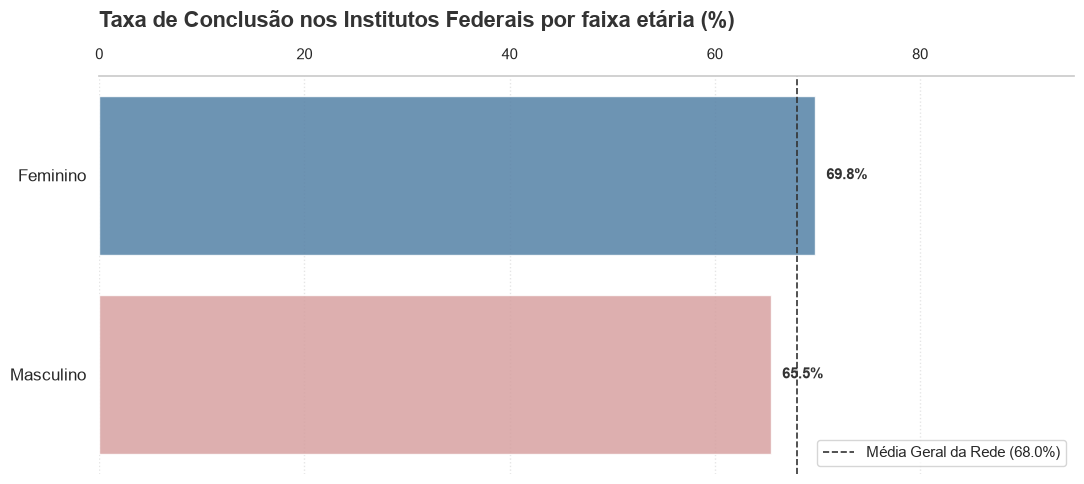

In [61]:
# 1. Ordenar o DataFrame de forma decrescente
df_sexo = df_sexo.sort_values(by='TAXA_CONCLUSAO', ascending=False).reset_index(drop=True)

# 2. Recalcular as cores na ordem decrescente exata
media_geral = (df['CONCLUINTES'].sum() / df['INGRESSANTES'].sum()) * 100
cores = ['#4682B4' if taxa >= media_geral else '#e09898' for taxa in df_sexo['TAXA_CONCLUSAO']]

# 3. Gerar o gráfico
plt.figure(figsize=(11, 5))
ax = plt.gca()

sns.barplot(
    data=df_sexo,
    x='TAXA_CONCLUSAO',
    y='SEXO',
    order=df_sexo['SEXO'],  # <-- Garante Maior (Sul) no topo até o Menor (Centro-Oeste) na base
    palette=cores,
    alpha=0.85
)

# Linha de referência da média geral
plt.axvline(media_geral, color='#333333', linestyle='--', linewidth=1.2, label=f'Média Geral da Rede ({media_geral:.1f}%)')

plt.title('Taxa de Conclusão nos Institutos Federais por faixa etária (%)', loc='left', pad=35, fontsize=16, weight='bold', color='#333333')
plt.xlabel('')
plt.ylabel('')

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.tick_params(axis='y', labelsize=12)

# Valores na ponta das barras
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.1f}%',
        (width, p.get_y() + p.get_height() / 2.),
        ha='left',
        va='center',
        xytext=(8, 0),
        textcoords='offset points',
        fontsize=11,
        weight='bold',
        color='#333333'
    )

ax.set_xlim(0, 95)
plt.grid(False, axis='y')
plt.grid(True, axis='x', linestyle=':', alpha=0.5, color='#cccccc')
sns.despine(left=True, bottom=True, top=False)
plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.tight_layout()
plt.show()


##### Agrupamento e seleção de observação por classe (perfil completo)

Com intuito de avaliar o efeito conjunto dos fatores demográficos: Cor, Renda, Idade e SEXO sobre a Taxa de Conclusão (Sucesso), foi criadas as variáveis total_ingressantes e total_concluintes pela soma dos valores das variáveis concluintes e ingressantes por agrupadas por estes fatores e formado o dataframe df_perfil associando os fatores agrupados (Perfis) a seus respectivos totais.

##### Criação da variável perfil

Para fins de analise foi criada a variável PERFIL pela concatenação das observações dos fatores: Cor/Raca, RENDA, FAIXA_ETARIA e SEXO.

In [62]:
colunas_perfil = ['RACA', 'RENDA', 'FAIXA_ETARIA', 'SEXO']

# 1. Atribui o código Perfil_01, Perfil_02, etc., para cada combinação única
df['PERFIL'] = 'Perfil_' + (df.groupby(colunas_perfil).ngroup() + 1).astype(str).str.zfill(2)

# 2. Recomendado: manter também a descrição completa para você saber quem é quem
df['DESCRICAO_PERFIL'] = df['RACA'] + " | " + df['RENDA'] + " | " + df['FAIXA_ETARIA'] + " | " + df['SEXO']

df[['PERFIL', 'DESCRICAO_PERFIL']].head()




,PERFIL,DESCRICAO_PERFIL
1,Perfil_573,Preta | Muito-Baixa | 20 a 24 | Masculino
2,Perfil_324,Indígena | Muito-Baixa | 50 a 54 | Masculino
3,Perfil_310,Indígena | Muito-Baixa | 15 a 19 | Masculino
4,Perfil_529,Preta | Alta | 20 a 24 | Masculino
5,Perfil_551,Preta | Baixa | 20 a 24 | Masculino


In [ ]:
# Agrupando por PERFIL Demográfico
perfil_cols = ['RACA', 'RENDA', 'FAIXA_ETARIA', 'SEXO']

# Somamos o total histórico de ingressantes e concluintes para cada perfil
df_perfil = df.groupby(perfil_cols).agg(
    total_ingressantes=('INGRESSANTES', 'sum'),
    total_concluintes=('CONCLUINTES', 'sum')
).reset_index()

##### Filtro de possíveis outliers

De modo a evitar a geração de vieses por classes com baixo número de observações (outliers estatísticos), foi estabelecido **corte amostral** e apenas classes com mais de 100 observações (alunos ingressantes) foram mantidas para a etapa de ranqueamento.

In [ ]:
# 1. Selecionar os 10 perfis com maior número de ingressantes
top_ingressantes = df_perfil.sort_values(by='total_ingressantes', ascending=False).head(10)

# 2. Configurar o gráfico
plt.figure(figsize=(12, 6))
ax = plt.gca()

# Identificar a coluna de rótulo (seja 'PERFIL' ou 'Nome_PERFIL')
eixo_y = 'PERFIL' if 'PERFIL' in top_ingressantes.columns else 'Nome_PERFIL'

# 3. Plotar o barplot horizontal
sns.barplot(
    data=top_ingressantes,
    x='total_ingressantes',
    y=eixo_y,
    color='#4682B4',  # SteelBlue
    alpha=0.85
)

# 4. Título e eixos
plt.title(
    'Top 10 Perfis com Maior Volume de Alunos Ingressantes na Rede Federal',
    loc='left',
    pad=35,
    fontsize=16,
    weight='bold',
    color='#333333'
)
plt.xlabel('Total de Ingressantes', fontsize=12)
plt.ylabel('')

# Eixo X no topo
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# 5. Inserir o valor numérico na ponta de cada barra
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width):,}', 
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', 
        va='center',
        xytext=(8, 0), 
        textcoords='offset points',
        fontsize=11, 
        weight='bold', 
        color='#333333'
    )

# Dar margem à direita para o texto não ser cortado
ax.set_xlim(0, top_ingressantes['total_ingressantes'].max() * 1.15)

# Linhas de grade e estilo
plt.grid(False, axis='y')
plt.grid(True, axis='x', linestyle=':', alpha=0.5, color='#cccccc')
sns.despine(left=True, bottom=True, top=False)
plt.tight_layout()
plt.show()


In [ ]:
# Filtramos apenas grupos que tenham uma amostra mínima (ex: mais de 100 alunos no total da rede histórica)
df_perfil = df_perfil[df_perfil['total_ingressantes'] > 100].copy()

##### Cálculo da taxa de aprovação por classe (Cor, Renda, Idade e SEXO)

A taxa de aprovação foi criada a partir da relação entre as variáveis total_concluintes e o total_ingressantes por perfil e multiplicada por 100, gerando um indicador percentual de eficácia/sucesso.

In [ ]:
# Cálculo da Taxa de Conclusão
df_perfil['taxa_conclusao'] = (df_perfil['total_concluintes'] / df_perfil['total_ingressantes']) * 100

#### Criação da variável PERFIL

Para fins de analise foi criada a variável PERFIL pela concatenação das observações dos fatores: Cor/Raca, RENDA, FAIXA_ETARIA e SEXO.

In [ ]:
# Criar uma coluna de nome descritivo do perfil para gráficos
df_perfil['PERFIL'] = df_perfil['RACA'] + " | " + df_perfil['RENDA'] + " | " + df_perfil['FAIXA_ETARIA'] + " | " + df_perfil['SEXO']
df_perfil.head()

#### Análise gráfica

#### Gráfico 01

Com objetivo de identificar quais perfis sociodemográficos apresentaram melhores taxas de conclusão e quais apresentaram piores taxas de conclusão (maiores risco de evasão) no período do estudo (2017 a 2025), os perfis foram ordenados de forma ascendentes a taxa de conclusão e selecionados (df_extremos) os cinco primeiros ranqueados (Melhores taxas) e os cinco útlimos ranqueados (Piores taxas) para serem plotados em **gráfico de barras horizontal**.

A média geral da taxa de conclusão em toda a rede serviu como linha base para fins de comparação.

In [ ]:
# Ordenar de forma ascedente quanto a taxa de conclusão
df_perfil = df_perfil.sort_values(by=['taxa_conclusao'], ascending=False)

# Selecionar os 10 maiores e os 10 menores
top = df_perfil.head(5).copy()
bottom = df_perfil.tail(5).copy()

# Concatenar para um único DataFrame
df_extremos = pd.concat([top, bottom])

# Paleta de cores
cores = ['#4682B4'] * 5 + ['#e09898'] * 5

plt.figure(figsize=(14, 10))
ax = plt.gca() # Obtém o eixo atual do gráfico

# Desenhar as barras sem marcadores de desvio (errorbar=None ou ci=None)
# alpha=0.85 foi usado para suavizar a saturação da cor
sns.barplot(
    data=df_extremos, 
    x='taxa_conclusao', 
    y='Nome_PERFIL', 
    palette=cores, 
    alpha=0.85,
    errorbar=None
)

# 3. Título alinhado à esquerda e com espaçamento
plt.title(
    'Perfis com as 5 melhores vs 5 piores taxas de Conclusão(%)', 
    loc='left', 
    pad=40, 
    fontsize=24, 
    weight='bold', 
    color='#333333'
)

# 4. Retirar os títulos dos eixos X e Y
plt.xlabel('')
plt.ylabel('')

# 5. Colocar o eixo X no topo do gráfico
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x',labelsize=12)

# 6. Alinhar os valores do eixo Y à esquerda
# ha='left' alinha o texto à esquerda. O pad empurra as labels para fora da barra/linha do eixo y.
ax.set_yticklabels(ax.get_yticklabels(), ha='left')
ax.tick_params(axis='y',labelsize=14, pad=300) # Ajuste este valor (ex: 220) conforme o comprimento dos textos

# 7. Eliminar as linhas de grade verticais e configurar as horizontais
plt.grid(False, axis='x')  # Remove linhas verticais
plt.grid(True, axis='y', linestyle=':', alpha=0.5, color='#cccccc') # Linhas horizontais discretas

# Linha da média geral (azul desaturado/suave)
media_geral = (df['CONCLUINTES'].sum() / df['INGRESSANTES'].sum()) * 100
plt.axvline(media_geral, color='#4682b4', linestyle='--', linewidth=1.5, label=f'Média Geral da Rede ({media_geral:.1f}%)')

# Ajustar legenda e remover bordas desnecessárias
plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')
sns.despine(left=True, bottom=True, top=False) # Remove linhas da borda esquerda e inferior

plt.show()

## Análise por cada um dos fatores sociodemográfico

Para compreender o peso individual de cada fator, foram gerados gráficos de barras que isolavam o impacto exclusivo da **Renda**, da **Cor/Raça**, **Idade** e **SEXO** sobre a Taxa de Conclusão.

### Por Renda

In [ ]:
df_renda = df.groupby('RENDA').agg(
    ingressantes=('INGRESSANTES', 'sum'),
    concluintes=('CONCLUINTES', 'sum')
).reset_index()

df_renda['taxa_conclusao'] = (df_renda['concluintes'] / df_renda['ingressantes']) * 100
df_renda = df_renda.sort_values(by='taxa_conclusao', ascending=False)

plt.figure(figsize=(12, 6))
ax = plt.gca()

# X e Y invertidos para ficar horizontal
sns.barplot(
    data=df_renda, 
    x='taxa_conclusao', 
    y='RENDA', 
    palette='coolwarm', 
    alpha=0.85, 
    errorbar=None)

# Estilizações prescritas no ranking
plt.title(
    'Taxa de conclusão por faixa de Renda Familiar Percapita (RFP)', 
    loc='left', 
    pad=40, 
    fontsize=18,
    weight='bold', 
    color='#333333'
    )

plt.xlabel('')
plt.ylabel('')

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Alinhamento das labels à esquerda (pad menor de 90 porque os nomes de renda são mais curtos)
ax.set_yticklabels(ax.get_yticklabels(), ha='left', fontsize=11)
ax.tick_params(axis='y', pad=70) 

# Grades pontilhadas apenas no eixo Y (horizontais)
plt.grid(False, axis='x')
plt.grid(True, axis='y', linestyle=':', alpha=0.5, color='#cccccc')
sns.despine(left=True, bottom=True, top=False)
plt.show()


### Por Cor/Raça

In [ ]:
df_cor = df.groupby('RACA').agg(
    ingressantes=('INGRESSANTES', 'sum'),
    concluintes=('CONCLUINTES', 'sum')
).reset_index()
df_cor['taxa_conclusao'] = (df_cor['concluintes'] / df_cor['ingressantes']) * 100
df_cor = df_cor.sort_values(by='taxa_conclusao', ascending=False)

plt.figure(figsize=(12, 4))
ax = plt.gca()

sns.barplot(
    data=df_cor, 
    x='taxa_conclusao', 
    y='RACA', 
    palette='coolwarm', 
    alpha=0.85, 
    errorbar=None)

plt.title(
    'Taxa de Conclusão por Cor/Raça', 
    loc='left', 
    pad=40, 
    fontsize=18, 
    weight='bold', 
    color='#333333'
    )

plt.xlabel('')
plt.ylabel('')
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Alinhamento à esquerda (pad de 75 é suficiente para os nomes de raça)
ax.set_yticklabels(ax.get_yticklabels(), ha='left', fontsize=11)
ax.tick_params(axis='y', pad=55)

plt.grid(False, axis='x')
plt.grid(True, axis='y', linestyle=':', alpha=0.5, color='#cccccc')
sns.despine(left=True, bottom=True, top=False)

plt.show()

### Por Faixa Etária

In [ ]:
df_idade = df.groupby('FAIXA_ETARIA').agg(
    ingressantes=('INGRESSANTES', 'sum'),
    concluintes=('CONCLUINTES', 'sum')
).reset_index()
df_idade['taxa_conclusao'] = (df_idade['concluintes'] / df_idade['ingressantes']) * 100
df_idade = df_idade.sort_values(by='taxa_conclusao', ascending=False)

plt.figure(figsize=(12, 9))
ax = plt.gca()

sns.barplot(
    data=df_idade, 
    x='taxa_conclusao', 
    y='FAIXA_ETARIA', 
    palette='coolwarm', 
    alpha=0.85, 
    errorbar=None)

plt.title(
    'Taxa de Conclusão por Faixa Etária', 
    loc='left', 
    pad=40, 
    fontsize=18, 
    weight='bold', 
    color='#333333'
    )

plt.xlabel('')
plt.ylabel('')
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Alinhamento à esquerda (pad de 60 é suficiente para os números de faixa etária)
ax.set_yticklabels(ax.get_yticklabels(), ha='left', fontsize=12)
ax.tick_params(axis='y', pad=50)

plt.grid(False, axis='x')
plt.grid(True, axis='y', linestyle=':', alpha=0.5, color='#cccccc')
sns.despine(left=True, bottom=True, top=False)
plt.show()

### Por SEXO

In [ ]:
df_SEXO = df.groupby('SEXO').agg(
    ingressantes=('INGRESSANTES', 'sum'),
    concluintes=('CONCLUINTES', 'sum')
).reset_index()
df_SEXO['taxa_conclusao'] = (df_SEXO['concluintes'] / df_SEXO['ingressantes']) * 100
df_SEXO = df_SEXO.sort_values(by='taxa_conclusao', ascending=False)

plt.figure(figsize=(12,2))
ax = plt.gca()

sns.barplot(
    data=df_SEXO, 
    x='taxa_conclusao', 
    y='SEXO', 
    palette='coolwarm_r', 
    alpha=0.85, 
    errorbar=None)

plt.title(
    'Taxa de Conclusão por SEXO', 
    loc='left', 
    pad=40, 
    fontsize=18, 
    weight='bold', 
    color='#333333'
    )

plt.xlabel('')
plt.ylabel('')
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Alinhamento à esquerda (pad de 60 é suficiente para as categorias da variável SEXO)
ax.set_yticklabels(ax.get_yticklabels(), ha='left', fontsize=12)
ax.tick_params(axis='y', pad=60)

plt.grid(False, axis='x')
plt.grid(True, axis='y', linestyle=':', alpha=0.5, color='#cccccc')
sns.despine(left=True, bottom=True, top=False)
plt.show()

## Mapa de Calor (Cor vs Renda)
Avaliar como os fatores Cor e Renda interagem estruturalmente.

In [ ]:
# Agrupamento e pivotamento (mantido igual)
df_intersec = df.groupby(['RACA', 'RENDA']).agg(
    ingressantes=('INGRESSANTES', 'sum'),
    concluintes=('CONCLUINTES', 'sum')
).reset_index()

df_intersec = df_intersec[df_intersec['ingressantes'] > 50].copy()
df_intersec['taxa_conclusao'] = (df_intersec['concluintes'] / df_intersec['ingressantes']) * 100

# Crie o pivot (como já está no seu código)
pivot = df_intersec.pivot(index='RENDA', columns='RACA', values='taxa_conclusao')

# 1. Defina a ordem desejada para as linhas (Eixo Y) e colunas (Eixo X)
ordem_renda = ['Alta', 'Média-Alta', 'Média', 'Média-Baixa', 'Baixa', 'Muito Baixa']
ordem_cor = ['Amarela', 'Branca', 'Parda', 'Preta', 'Indígena']

# 2. Aplique a reordenação em ambos os eixos ao mesmo tempo
pivot = pivot.reindex(index=ordem_renda, columns=ordem_cor)

# Configuração da figura
plt.figure(figsize=(10, 6))
ax = plt.gca()

# 1. cbar=False elimina a barra de cores lateral (legenda)
sns.heatmap(
    pivot, annot=True, 
    cmap='coolwarm_r', 
    fmt=".1f", 
    linewidths=.5, 
    cbar=False)

# 2. Título alinhado à esquerda
plt.title(
    'Mapa de Calor da Taxa de Conclusão (%): Cor/Raça vs Renda Familiar', 
    loc='left', 
    pad=40,
    ha='left', 
    fontsize=14, 
    weight='bold', 
    color='#333333')

# 3. Eliminar os títulos dos eixos
plt.xlabel('')
plt.ylabel('')

# 4. Colocar os valores do eixo X no topo
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', bottom=False, top=False)


# 5. Alinhar horizontalmente e à esquerda os valores do eixo Y
# rotation=0 garante que os textos fiquem perfeitamente horizontais
ax.set_yticklabels(ax.get_yticklabels(), ha='left', rotation=0, fontsize=11)
ax.tick_params(axis='y', pad=70) # pad de 100 para dar espaço aos nomes das rendas

plt.show()

## Teste de Significância Estatística (Qui-Quadrado)
O teste Qui-quadrado foi aplicado para avaliar a significância de cada variável sociodemográfica em relação a situação do aluno (Concluinte vs Não Concluinte). 

A utilização do teste Qui-quadrado foi a escolha ideal para este estudo, uma vez que se tratava de associação entre variáveis categóricas, baseando-se nas frequências observadas e esperadas de evasão/conclusão.

In [ ]:
from scipy.stats import chi2_contingency

def testar_significancia(df_base, coluna_grupo):
    df_grupo = df_base.groupby(coluna_grupo).agg(
        ingressantes=('INGRESSANTES', 'sum'),
        concluintes=('CONCLUINTES', 'sum')
    ).reset_index()
    
    # Calcular não concluintes
    df_grupo['nao_concluintes'] = df_grupo['ingressantes'] - df_grupo['concluintes']
    
    # Tabela de contingência
    tabela_contingencia = df_grupo[['concluintes', 'nao_concluintes']].values
    
    chi2, p, dof, expected = chi2_contingency(tabela_contingencia)
    
    print(f"--- Teste para a variável: {coluna_grupo} ---")
    print(f"Valor-p (p-value): {p:.2e}")
    if p < 0.05:
        print("Resultado: Estatisticamente SIGNIFICATIVA! (A diferença não é ao acaso)\n")
    else:
        print("Resultado: NÃO significativa. (As variações podem ser ao acaso)\n")

testar_significancia(df, 'RENDA')
testar_significancia(df, 'RACA')
testar_significancia(df, 'FAIXA_ETARIA')
testar_significancia(df, 'SEXO')

## Análise de Correspondência Múltipla (ACM)

Para visualizar a associação multidimensional entre as categorias de perfil (Cor/Raça, Renda, Idade, Gênero) e a situação de conclusão do aluno, aplicamos a Análise de Correspondência Múltipla (ACM), técnica essencial para explorar padrões simultâneos em múltiplas variáveis categóricas.

### Correção de Benzécri

Na ACM clássica, a variância explicada (inércia) pelas primeiras dimensões é tipicamente subestimada devido à expansão da matriz de dados para uma matriz indicadora binária (0 e 1), o que infla artificialmente a inércia total. Neste casos, faz-se necessário a aplicação da **Correção de Benzécri** nos autovalores do modelo a fim de corrigir esse efeito e apresentar um percentual mais realista da variância explicada pelas duas principais dimensões.

In [ ]:
import prince

# 1. Preparar os dados expandindo a contagem para registros individuais
perfil_cols = ['RACA', 'RENDA', 'FAIXA_ETARIA', 'SEXO']

# Agrupar pelos perfis para consolidar e limpar
df_agrupado = df.groupby(perfil_cols).agg(
    ingressantes=('INGRESSANTES', 'sum'),
    concluintes=('CONCLUINTES', 'sum')
).reset_index()

# Filtramos apenas perfis com amostra representativa (mais de 100 ingressantes historicamente)
df_agrupado = df_agrupado[df_agrupado['ingressantes'] > 100].copy()

# Criar lista de registros individuais
registros = []
for idx, row in df_agrupado.iterrows():
    c = int(row['concluintes'])
    nc = int(row['ingressantes'] - row['concluintes'])
    
    # Criamos os registros individuais
    for _ in range(c):
        registros.append({
            'RACA': row['RACA'],
            'RENDA': row['RENDA'],
            'FAIXA_ETARIA': row['FAIXA_ETARIA'],
            'SEXO': row['SEXO'],
            'Situacao': 'Concluinte'
        })
    for _ in range(nc):
        registros.append({
            'RACA': row['RACA'],
            'RENDA': row['RENDA'],
            'FAIXA_ETARIA': row['FAIXA_ETARIA'],
            'SEXO': row['SEXO'],
            'Situacao': 'Não Concluinte'
        })

df_individual = pd.DataFrame(registros)
print(f"Total de registros individuais gerados para a ACM: {len(df_individual)}")
df_individual.head()

In [ ]:
# Instanciar e ajustar o modelo ACM com a Correção de Benzécri
# A correção de Benzécri ajusta os autovalores (eigenvalues) para corrigir a subestimação
# da inércia explicada gerada pela matriz indicadora binária.
mca = prince.MCA(
    n_components=2,
    n_iter=5,
    copy=True,
    check_input=True,
    engine='sklearn',
    correction='benzecri',  # Aplica a correção de Benzécri nativamente
    random_state=42
)
mca = mca.fit(df_individual)

# 3. Obter as coordenadas das categorias
col_coords = mca.column_coordinates(df_individual)
col_coords.columns = ['Dim 1', 'Dim 2']

# Inércia explicada (com correção de Benzécri já aplicada)
percent_expl = mca.percentage_of_variance_
print(f"Inércia explicada na Dim 1 (Corrigida por Benzécri): {percent_expl[0]:.2f}%")
print(f"Inércia explicada na Dim 2 (Corrigida por Benzécri): {percent_expl[1]:.2f}%")
col_coords.head()

### Gráfico Biplot

O gráfico gerado pela ACM permite identificar, em um plano cartesiano 2D, quais categorias demográficas estão fortemente associadas à taxa de conclusão (Concluinte) e a de não conclusão (Não Concluinte), fornecendo um retrato consolidado da desigualdade estrutural.

In [ ]:
# 4. Plotar o Biplot com matplotlib e seaborn
plt.figure(figsize=(14, 10))

# Processar os labels do índice para melhor apresentação visual
categorias = col_coords.index.tolist()
variaveis = []
labels_limpos = []

for cat in categorias:
    for var in ['RACA', 'RENDA', 'FAIXA_ETARIA', 'SEXO', 'Situacao']:
        if cat.startswith(var):
            variaveis.append(var)
            labels_limpos.append(cat.replace(var + '_', ''))
            break
    else:
        variaveis.append('Outros')
        labels_limpos.append(cat)

col_coords['Variavel'] = variaveis
col_coords['Label_Limpa'] = labels_limpos

# Plot dos pontos
sns.scatterplot(
    data=col_coords, 
    x='Dim 1', 
    y='Dim 2', 
    hue='Variavel', 
    style='Variavel', 
    s=180, 
    palette='Set1',
    edgecolor='black',
    linewidth=0.8
)

# Adicionar labels textuais
for idx, row in col_coords.iterrows():
    if row['Variavel'] == 'Situacao':
        # Destacar os desfechos Concluinte / Não Concluinte
        cor_fundo = '#ffe6e6' if 'Não' in row['Label_Limpa'] else '#e6ffe6'
        plt.text(
            row['Dim 1'] + 0.02, 
            row['Dim 2'], 
            row['Label_Limpa'], 
            fontsize=13, 
            weight='bold', 
            color='black',
            bbox=dict(facecolor=cor_fundo, edgecolor='black', alpha=0.9, boxstyle='round,pad=0.4')
        )
    else:
        plt.text(
            row['Dim 1'] + 0.015, 
            row['Dim 2'] + 0.005, 
            row['Label_Limpa'], 
            fontsize=10.5, 
            color='darkslategray',
            weight='semibold'
        )

# Desenhar eixos centrais
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

plt.title(
    f'Biplot da Análise de Correspondência Múltipla (ACM) com Correção de Benzécri Dim 1 ({percent_expl[0]:.2f}%) vs Dim 2 ({percent_expl[1]:.2f}%)', 
    fontsize=14, 
    weight='bold', 
    pad=15)

plt.xlabel(f'Dimensão 1 ({percent_expl[0]:.2f}%)', fontsize=12, labelpad=10)
plt.ylabel(f'Dimensão 2 ({percent_expl[1]:.2f}%)', fontsize=12, labelpad=10)
plt.legend(title='Variáveis', title_fontsize='11', loc='best', frameon=True)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()